# 📦 01 — SAHI Preprocessing: Slice Dense Retail Shelf Images

This notebook slices high-resolution retail shelf images (~3000×4000 px) into
overlapping **640×640** tiles suitable for YOLO training.

### Why Slice?
- Original images contain up to **1,373 densely packed objects**
- Training at `imgsz=640` without slicing shrinks each product to ~1–3 pixels
- Slicing preserves native resolution so the model can actually learn features

### Parameters
| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Tile Size | 640×640 | Matches YOLO training `imgsz` |
| Overlap | 20% (128 px) | Prevents objects at tile borders from being cut |
| Min BBox Area | 10% of original | Filters heavily clipped edge objects |

In [1]:
# ============================================================
#  Imports
# ============================================================

import os
import sys
import shutil
from pathlib import Path
from PIL import Image
import numpy as np
from tqdm.notebook import tqdm
import yaml
import time
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print(f"Python: {sys.version}")
print("Imports complete ✓")

Python: 3.10.20 (main, Jun 11 2026, 15:17:37) [GCC 14.3.0]
Imports complete ✓


In [2]:
# ============================================================
#  Configuration
# ============================================================

# --- Paths (relative to this notebook's location) ---
PROJECT_ROOT = Path("..")
SOURCE_DIR   = PROJECT_ROOT / "Dataset"          # Original dataset
OUTPUT_DIR   = PROJECT_ROOT / "dataset_sliced"    # Sliced output

# --- Slicing Parameters ---
SLICE_WIDTH       = 640     # Tile width in pixels
SLICE_HEIGHT      = 640     # Tile height in pixels
OVERLAP_RATIO     = 0.20    # 20% overlap between adjacent tiles

# --- Filtering Parameters ---
MIN_BBOX_AREA_RATIO  = 0.10   # Keep bbox only if ≥10% of original area remains after clipping
MIN_BBOX_PIXEL_AREA  = 16     # Absolute minimum bbox area (pixels²) to keep

# --- Splits to Process ---
SPLITS = ["train", "val"]   # Test set is NOT sliced (SAHI handles it at inference)

print(f"Source:  {SOURCE_DIR.resolve()}")
print(f"Output:  {OUTPUT_DIR.resolve()}")
print(f"Tile:    {SLICE_WIDTH}×{SLICE_HEIGHT}, Overlap: {OVERLAP_RATIO*100:.0f}%")
print(f"Stride:  {int(SLICE_WIDTH * (1 - OVERLAP_RATIO))} px")

Source:  /home/rakib/Desktop/OFFICE/Projects/ALL Products/Dataset
Output:  /home/rakib/Desktop/OFFICE/Projects/ALL Products/dataset_sliced
Tile:    640×640, Overlap: 20%
Stride:  512 px


## 🔧 Core Slicing Functions

In [3]:
def calculate_slice_positions(img_width, img_height, slice_w, slice_h, overlap):
    """
    Calculate (x, y) start positions for tiling an image.
    
    Ensures full coverage by adding a final tile at the image boundary
    if the regular stride doesn't reach the edge.
    
    Args:
        img_width:  Original image width
        img_height: Original image height
        slice_w:    Tile width
        slice_h:    Tile height
        overlap:    Overlap ratio (0.0 to 1.0)
    
    Returns:
        (x_positions, y_positions): Lists of top-left corner coordinates
    """
    stride_x = int(slice_w * (1 - overlap))
    stride_y = int(slice_h * (1 - overlap))
    
    # Generate positions along X axis
    x_positions = list(range(0, max(1, img_width - slice_w + 1), stride_x))
    if len(x_positions) == 0:
        x_positions = [0]
    elif x_positions[-1] + slice_w < img_width:
        x_positions.append(img_width - slice_w)  # Final edge tile
    
    # Generate positions along Y axis
    y_positions = list(range(0, max(1, img_height - slice_h + 1), stride_y))
    if len(y_positions) == 0:
        y_positions = [0]
    elif y_positions[-1] + slice_h < img_height:
        y_positions.append(img_height - slice_h)  # Final edge tile
    
    return x_positions, y_positions


def load_yolo_labels(label_path):
    """
    Load YOLO-format labels from a .txt file.
    
    Returns:
        List of tuples: [(class_id, cx, cy, w, h), ...]
        All values are normalized (0.0–1.0) except class_id (int).
    """
    bboxes = []
    if not label_path.exists():
        return bboxes
    
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(float(parts[0]))
                cx, cy, w, h = map(float, parts[1:5])
                bboxes.append((cls_id, cx, cy, w, h))
    
    return bboxes


def transform_bboxes_to_tile(bboxes, tile_x, tile_y, tile_w, tile_h,
                              img_w, img_h, min_area_ratio, min_pixel_area):
    """
    Transform YOLO bounding boxes from full-image coordinates to tile coordinates.
    
    Process:
    1. Convert normalized → absolute coordinates
    2. Clip bbox to the tile's region
    3. Filter out bboxes that lost too much area (edge artifacts)
    4. Re-normalize to tile's coordinate system
    
    Args:
        bboxes:         List of (cls_id, cx, cy, w, h) in normalized image coords
        tile_x, tile_y: Top-left corner of the tile in absolute image coords
        tile_w, tile_h: Tile dimensions in pixels
        img_w, img_h:   Original image dimensions
        min_area_ratio: Minimum fraction of original bbox area to keep
        min_pixel_area: Minimum absolute area in pixels to keep
    
    Returns:
        List of (cls_id, cx, cy, w, h) in normalized tile coordinates
    """
    transformed = []
    
    for cls_id, cx, cy, w, h in bboxes:
        # --- Step 1: Normalized → Absolute (full image) ---
        abs_cx = cx * img_w
        abs_cy = cy * img_h
        abs_w  = w * img_w
        abs_h  = h * img_h
        
        # Bbox corners in absolute coords
        x1 = abs_cx - abs_w / 2.0
        y1 = abs_cy - abs_h / 2.0
        x2 = abs_cx + abs_w / 2.0
        y2 = abs_cy + abs_h / 2.0
        
        original_area = abs_w * abs_h
        
        # --- Step 2: Clip to tile region ---
        clip_x1 = max(x1, tile_x)
        clip_y1 = max(y1, tile_y)
        clip_x2 = min(x2, tile_x + tile_w)
        clip_y2 = min(y2, tile_y + tile_h)
        
        clip_w = clip_x2 - clip_x1
        clip_h = clip_y2 - clip_y1
        
        # Skip if bbox doesn't intersect tile at all
        if clip_w <= 0 or clip_h <= 0:
            continue
        
        # --- Step 3: Area-based filtering ---
        clipped_area = clip_w * clip_h
        
        # Skip if too little of the original bbox remains
        if original_area > 0 and (clipped_area / original_area) < min_area_ratio:
            continue
        
        # Skip if remaining bbox is tiny (noise)
        if clipped_area < min_pixel_area:
            continue
        
        # --- Step 4: Re-normalize to tile coordinates ---
        new_cx = ((clip_x1 + clip_x2) / 2.0) - tile_x
        new_cy = ((clip_y1 + clip_y2) / 2.0) - tile_y
        
        norm_cx = np.clip(new_cx / tile_w, 0.0, 1.0)
        norm_cy = np.clip(new_cy / tile_h, 0.0, 1.0)
        norm_w  = np.clip(clip_w / tile_w,  0.0, 1.0)
        norm_h  = np.clip(clip_h / tile_h,  0.0, 1.0)
        
        transformed.append((cls_id, float(norm_cx), float(norm_cy),
                            float(norm_w), float(norm_h)))
    
    return transformed


print("Core functions defined ✓")

Core functions defined ✓


## 🚀 Main Slicing Pipeline

In [4]:
def slice_split(split_name, source_dir, output_dir, config):
    """
    Slice all images in a dataset split into overlapping tiles.
    
    Args:
        split_name: 'train' or 'val'
        source_dir: Path to original Dataset/
        output_dir: Path to dataset_sliced/
        config:     Dict with slicing parameters
    
    Returns:
        Dict with statistics
    """
    src_img_dir = source_dir / split_name / "images"
    src_lbl_dir = source_dir / split_name / "labels"
    dst_img_dir = output_dir / split_name / "images"
    dst_lbl_dir = output_dir / split_name / "labels"
    
    # Create output directories
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.mkdir(parents=True, exist_ok=True)
    
    # Gather all image files
    image_files = sorted(
        list(src_img_dir.glob("*.jpg")) +
        list(src_img_dir.glob("*.jpeg")) +
        list(src_img_dir.glob("*.png"))
    )
    
    stats = {
        "total_images": len(image_files),
        "total_tiles": 0,
        "total_annotations": 0,
        "skipped_empty_tiles": 0,
        "tiles_per_image": [],
    }
    
    for img_path in tqdm(image_files, desc=f"Slicing [{split_name}]", unit="img"):
        # Load image
        img = Image.open(img_path)
        img_w, img_h = img.size
        
        # Load corresponding labels
        label_path = src_lbl_dir / f"{img_path.stem}.txt"
        bboxes = load_yolo_labels(label_path)
        
        # Calculate tile positions
        x_positions, y_positions = calculate_slice_positions(
            img_w, img_h,
            config["slice_width"], config["slice_height"],
            config["overlap_ratio"]
        )
        
        img_tile_count = 0
        
        for yi, y in enumerate(y_positions):
            for xi, x in enumerate(x_positions):
                # Crop tile from image
                tile = img.crop((
                    x, y,
                    x + config["slice_width"],
                    y + config["slice_height"]
                ))
                
                # Transform bounding boxes to tile coordinates
                tile_bboxes = transform_bboxes_to_tile(
                    bboxes, x, y,
                    config["slice_width"], config["slice_height"],
                    img_w, img_h,
                    config["min_area_ratio"],
                    config["min_pixel_area"]
                )
                
                # Skip tiles with no annotations (empty shelf edges)
                if len(tile_bboxes) == 0:
                    stats["skipped_empty_tiles"] += 1
                    continue
                
                # Save tile image
                tile_name = f"{img_path.stem}__tile_r{yi}_c{xi}"
                tile.save(dst_img_dir / f"{tile_name}.jpg", quality=95)
                
                # Save tile labels
                with open(dst_lbl_dir / f"{tile_name}.txt", "w") as f:
                    for bbox in tile_bboxes:
                        f.write(f"{bbox[0]} {bbox[1]:.6f} {bbox[2]:.6f} "
                                f"{bbox[3]:.6f} {bbox[4]:.6f}\n")
                
                stats["total_tiles"] += 1
                stats["total_annotations"] += len(tile_bboxes)
                img_tile_count += 1
        
        stats["tiles_per_image"].append(img_tile_count)
        img.close()
    
    return stats


print("Slicing pipeline defined ✓")

Slicing pipeline defined ✓


## ▶️ Execute Slicing

In [5]:
# ============================================================
#  Clean previous output (if re-running)
# ============================================================

if OUTPUT_DIR.exists():
    print(f"Removing existing sliced dataset: {OUTPUT_DIR}")
    shutil.rmtree(OUTPUT_DIR)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory created: {OUTPUT_DIR.resolve()}")

Output directory created: /home/rakib/Desktop/OFFICE/Projects/ALL Products/dataset_sliced


In [6]:
# ============================================================
#  Run slicing on train and val splits
# ============================================================

slicing_config = {
    "slice_width":    SLICE_WIDTH,
    "slice_height":   SLICE_HEIGHT,
    "overlap_ratio":  OVERLAP_RATIO,
    "min_area_ratio": MIN_BBOX_AREA_RATIO,
    "min_pixel_area": MIN_BBOX_PIXEL_AREA,
}

all_stats = {}
start_time = time.time()

for split in SPLITS:
    print(f"\n{'='*60}")
    print(f"  Processing: {split.upper()}")
    print(f"{'='*60}")
    
    stats = slice_split(split, SOURCE_DIR, OUTPUT_DIR, slicing_config)
    all_stats[split] = stats
    
    # Print summary for this split
    tiles_arr = np.array(stats["tiles_per_image"])
    print(f"\n  📊 {split.upper()} Summary:")
    print(f"     Original images:    {stats['total_images']}")
    print(f"     Generated tiles:    {stats['total_tiles']}")
    print(f"     Total annotations:  {stats['total_annotations']}")
    print(f"     Skipped (empty):    {stats['skipped_empty_tiles']}")
    print(f"     Tiles/image:        {tiles_arr.mean():.1f} avg, "
          f"{tiles_arr.min()} min, {tiles_arr.max()} max")
    print(f"     Annotations/tile:   {stats['total_annotations']/max(1,stats['total_tiles']):.1f} avg")

elapsed = time.time() - start_time
print(f"\n⏱️  Total time: {elapsed/60:.1f} minutes")


  Processing: TRAIN


Slicing [train]:   0%|          | 0/600 [00:00<?, ?img/s]


  📊 TRAIN Summary:
     Original images:    600
     Generated tiles:    21677
     Total annotations:  310405
     Skipped (empty):    3235
     Tiles/image:        36.1 avg, 6 min, 63 max
     Annotations/tile:   14.3 avg

  Processing: VAL


Slicing [val]:   0%|          | 0/128 [00:00<?, ?img/s]


  📊 VAL Summary:
     Original images:    128
     Generated tiles:    4702
     Total annotations:  58856
     Skipped (empty):    812
     Tiles/image:        36.7 avg, 4 min, 63 max
     Annotations/tile:   12.5 avg

⏱️  Total time: 2.0 minutes


## 📄 Generate `data.yaml` for Sliced Dataset

In [7]:
# ============================================================
#  Generate data.yaml for the sliced dataset
# ============================================================

# Use absolute path to avoid any resolution issues with Ultralytics
sliced_data_yaml = {
    "path": str(OUTPUT_DIR.resolve()),
    "train": "train/images",
    "val":   "val/images",
    "names": {
        0: "product"
    }
}

yaml_path = OUTPUT_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(sliced_data_yaml, f, default_flow_style=False, sort_keys=False)

print(f"✅ data.yaml written to: {yaml_path.resolve()}")
print(f"\nContents:")
print("-" * 40)
with open(yaml_path, "r") as f:
    print(f.read())

✅ data.yaml written to: /home/rakib/Desktop/OFFICE/Projects/ALL Products/dataset_sliced/data.yaml

Contents:
----------------------------------------
path: /home/rakib/Desktop/OFFICE/Projects/ALL Products/dataset_sliced
train: train/images
val: val/images
names:
  0: product



## 🔍 Visual Verification

Spot-check random tiles to verify bounding boxes align correctly.

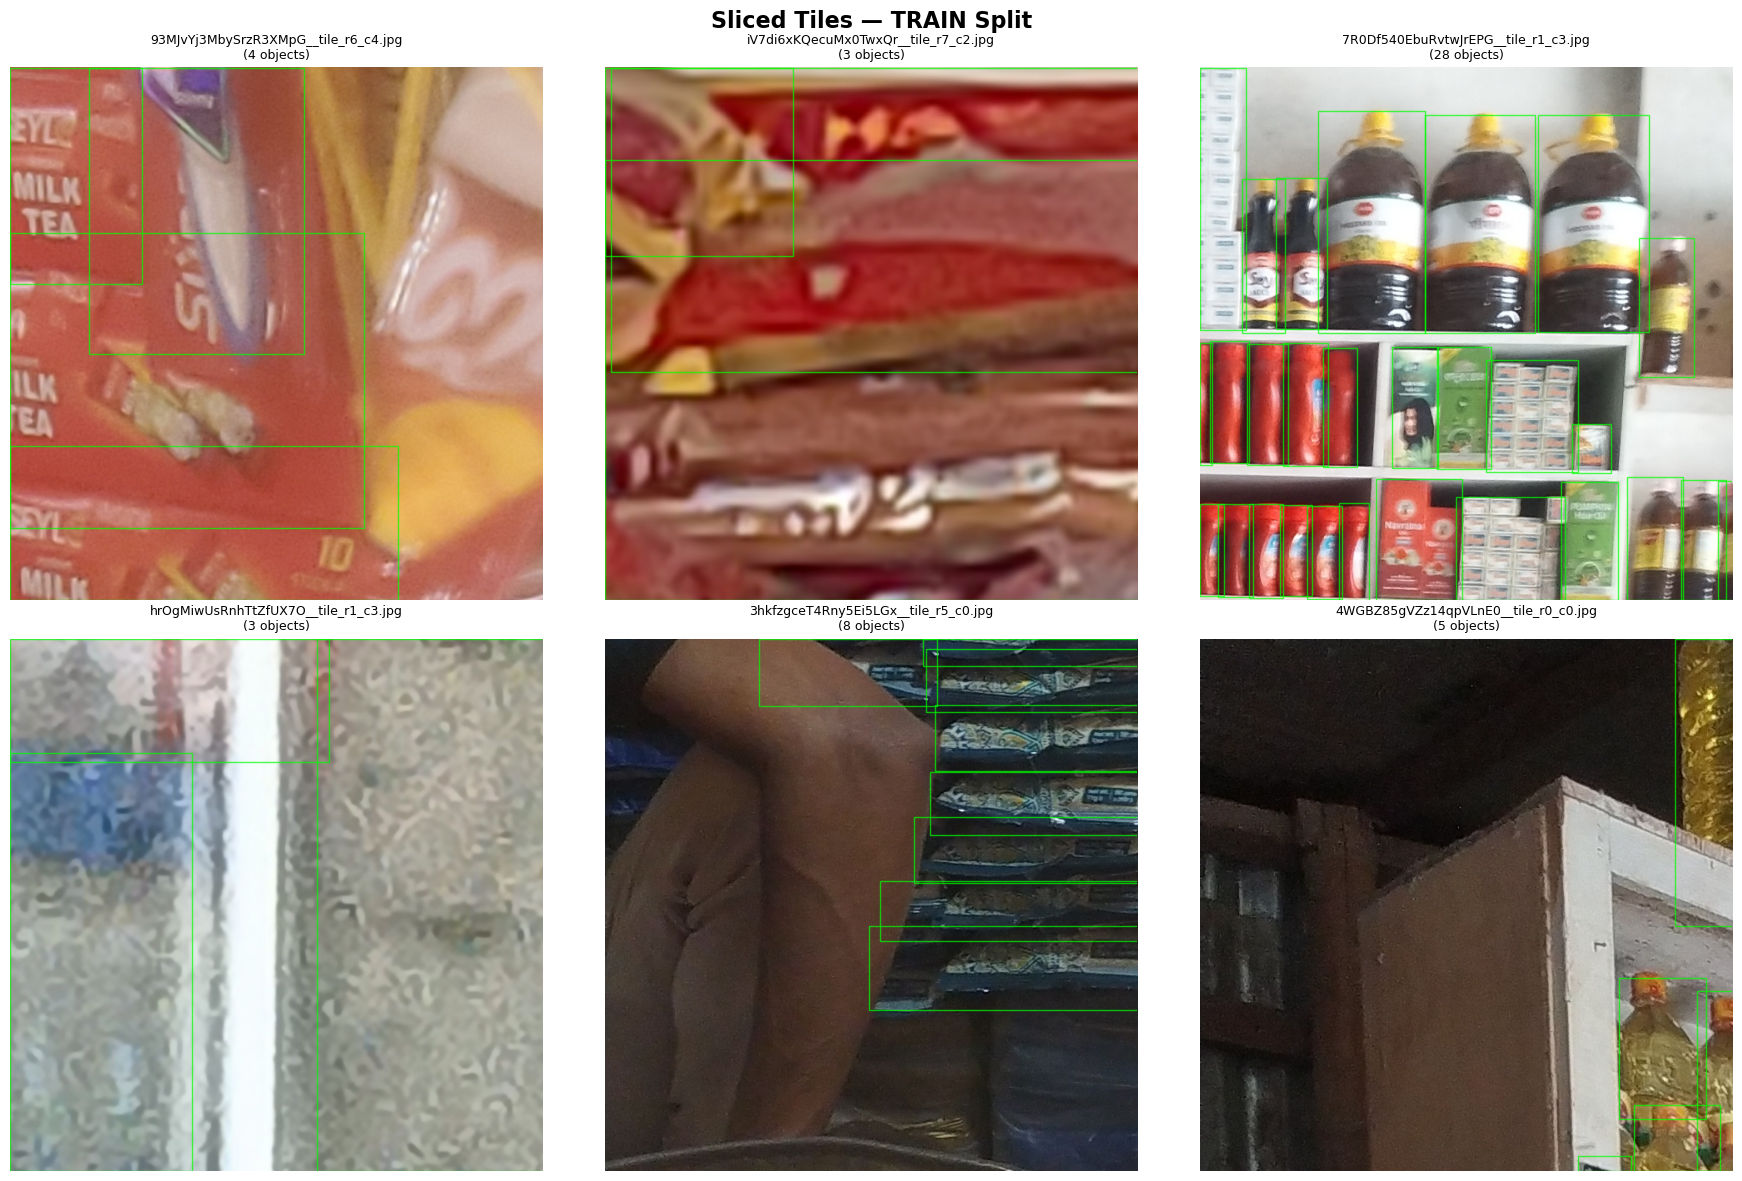

In [8]:
# ============================================================
#  Visualize random sliced tiles with their bounding boxes
# ============================================================

def visualize_tiles(split, output_dir, num_samples=6):
    """Display random tiles with their YOLO bboxes overlaid."""
    img_dir = output_dir / split / "images"
    lbl_dir = output_dir / split / "labels"
    
    tile_images = list(img_dir.glob("*.jpg"))
    samples = random.sample(tile_images, min(num_samples, len(tile_images)))
    
    cols = 3
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
    if rows == 1:
        axes = [axes]
    axes = np.array(axes).flatten()
    
    for idx, img_path in enumerate(samples):
        ax = axes[idx]
        img = Image.open(img_path)
        ax.imshow(img)
        
        # Load and draw bboxes
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if lbl_path.exists():
            bboxes = load_yolo_labels(lbl_path)
            for cls_id, cx, cy, w, h in bboxes:
                # Convert normalized → pixel coords
                px = (cx - w/2) * SLICE_WIDTH
                py = (cy - h/2) * SLICE_HEIGHT
                pw = w * SLICE_WIDTH
                ph = h * SLICE_HEIGHT
                
                rect = patches.Rectangle(
                    (px, py), pw, ph,
                    linewidth=1.0, edgecolor="lime",
                    facecolor="none", alpha=0.7
                )
                ax.add_patch(rect)
            
            ax.set_title(f"{img_path.name}\n({len(bboxes)} objects)", fontsize=9)
        
        ax.axis("off")
    
    # Hide unused axes
    for idx in range(len(samples), len(axes)):
        axes[idx].axis("off")
    
    plt.suptitle(f"Sliced Tiles — {split.upper()} Split", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Visualize train tiles
visualize_tiles("train", OUTPUT_DIR, num_samples=6)

In [9]:
# ============================================================
#  Final Summary
# ============================================================

print("\n" + "=" * 60)
print("  ✅ PREPROCESSING COMPLETE")
print("=" * 60)
print(f"\n  Sliced dataset location: {OUTPUT_DIR.resolve()}")
print(f"  data.yaml:               {(OUTPUT_DIR / 'data.yaml').resolve()}")

for split in SPLITS:
    n_imgs = len(list((OUTPUT_DIR / split / "images").glob("*.jpg")))
    n_lbls = len(list((OUTPUT_DIR / split / "labels").glob("*.txt")))
    print(f"\n  {split.upper()}:")
    print(f"    Images: {n_imgs}")
    print(f"    Labels: {n_lbls}")

print(f"\n  👉 Next step: Run 02_train.ipynb")


  ✅ PREPROCESSING COMPLETE

  Sliced dataset location: /home/rakib/Desktop/OFFICE/Projects/ALL Products/dataset_sliced
  data.yaml:               /home/rakib/Desktop/OFFICE/Projects/ALL Products/dataset_sliced/data.yaml

  TRAIN:
    Images: 21677
    Labels: 21677

  VAL:
    Images: 4702
    Labels: 4702

  👉 Next step: Run 02_train.ipynb
